## Imports and Data Ingestion

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [2]:
try:
    df_before_raw = pd.read_csv('performance_before.csv')
    df_after_raw = pd.read_csv('performance_after.csv')
    display(HTML("<h3>Metrics Log Files Loaded Successfully</h3>"))
except FileNotFoundError:
    display(HTML("<h3 style='color:red;'>Performance CSV files not found.</h3>"))
    raise

In [3]:
# Isolating only the summary AVERAGE data profiles
df_before_avg = df_before_raw[df_before_raw['Architecture'].str.contains('AVERAGE')].copy()
df_after_avg = df_after_raw[df_after_raw['Architecture'].str.contains('AVERAGE')].copy()

In [4]:
# Standardise names
df_before_avg['Architecture'] = df_before_avg['Architecture'].str.replace(' (AVERAGE)', '', regex=False)
df_after_avg['Architecture'] = df_after_avg['Architecture'].str.replace(' (AVERAGE)', '', regex=False)

In [5]:
# Combine the averages into a single evaluation matrix
df_eval = pd.concat([df_before_avg, df_after_avg], ignore_index=True)

display(df_eval)
sns.set_theme(style="whitegrid")

,Architecture,Latency (s),Memory (MB),CPU Load (%),Throughput (records/s)
0,Baseline (Sequential),14.7959,26.32,63.7,6420.95
1,Tech 1 (MP Pool),14.4334,33.68,98.0,6582.22
2,Tech 2 (Hybrid Vectorized),0.9445,38.62,76.8,100591.87


## Execution Latency

/tmp/ipykernel_5427/1833830037.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_time = sns.barplot(x="Architecture", y="Latency (s)", data=df_eval, palette="viridis")


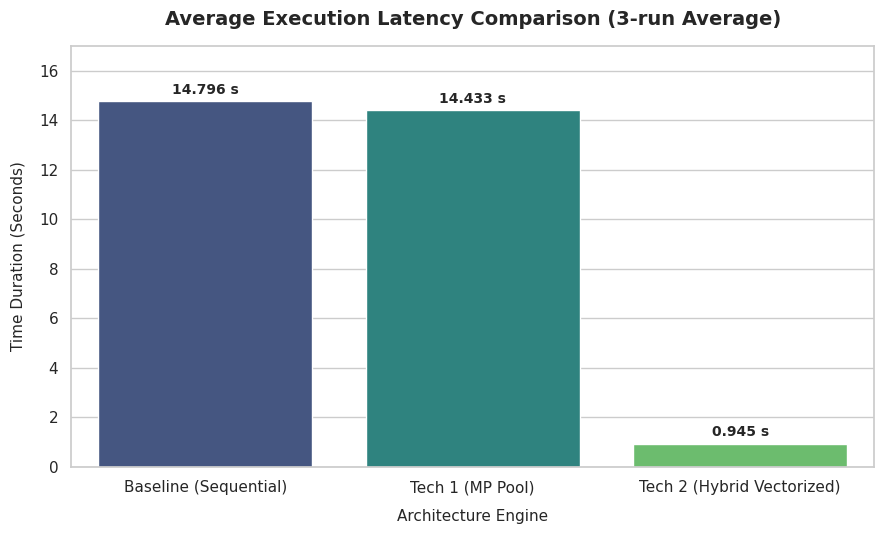

In [6]:
plt.figure(figsize=(9, 5.5))
barplot_time = sns.barplot(x="Architecture", y="Latency (s)", data=df_eval, palette="viridis")

plt.title("Average Execution Latency Comparison (3-run Average)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Architecture Engine", fontsize=11, labelpad=10)
plt.ylabel("Time Duration (Seconds)", fontsize=11, labelpad=10)
plt.ylim(0, df_eval['Latency (s)'].max() * 1.15)

for patch in barplot_time.patches:
    barplot_time.annotate(f"{patch.get_height():.3f} s",
                          (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                          ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                          fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Peak Memory Chart

/tmp/ipykernel_5427/3616242951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_mem = sns.barplot(x="Architecture", y="Memory (MB)", data=df_eval, palette="magma")


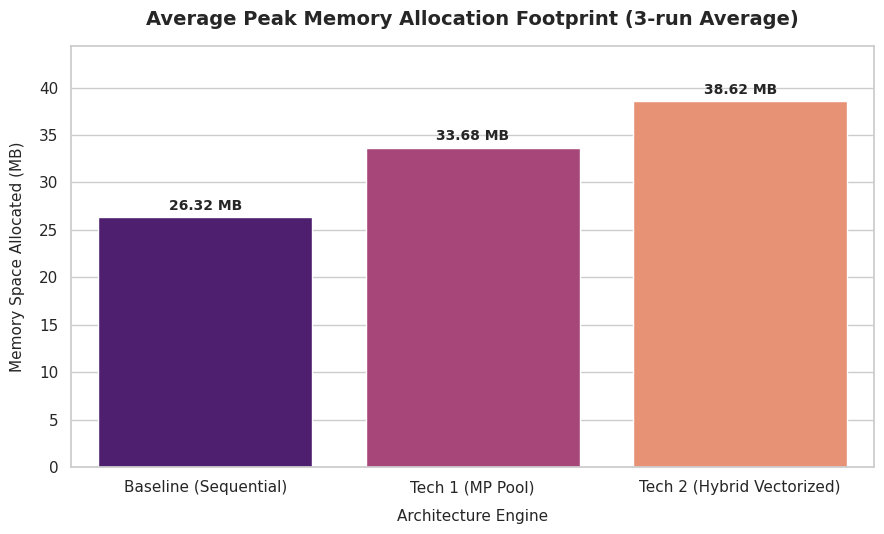

In [7]:
plt.figure(figsize=(9, 5.5))
barplot_mem = sns.barplot(x="Architecture", y="Memory (MB)", data=df_eval, palette="magma")

plt.title("Average Peak Memory Allocation Footprint (3-run Average)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Architecture Engine", fontsize=11, labelpad=10)
plt.ylabel("Memory Space Allocated (MB)", fontsize=11, labelpad=10)
plt.ylim(0, df_eval['Memory (MB)'].max() * 1.15)

for patch in barplot_mem.patches:
    barplot_mem.annotate(f"{patch.get_height():.2f} MB",
                          (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                          ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                          fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## CPU Workload Distribution Chart

/tmp/ipykernel_5427/1008801874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_cpu = sns.barplot(x="Architecture", y="CPU Load (%)", data=df_eval, palette="coolwarm")


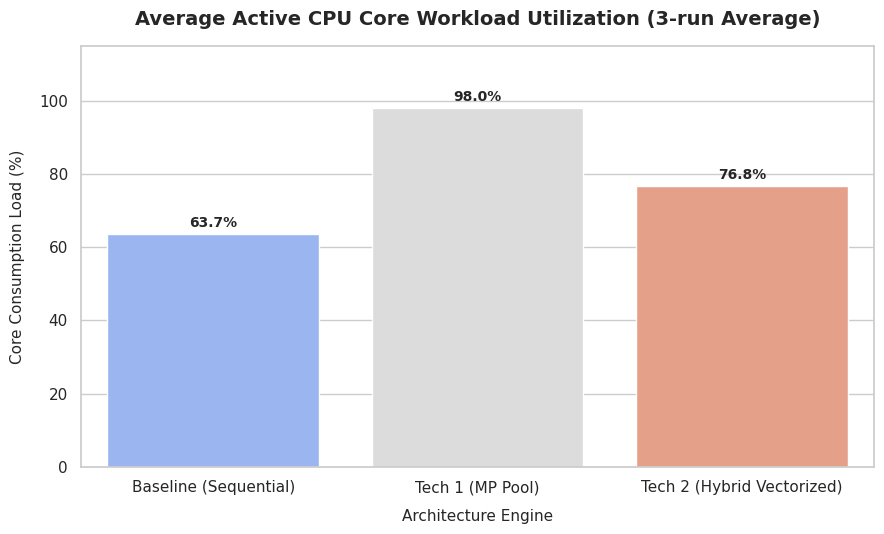

In [8]:
plt.figure(figsize=(9, 5.5))
barplot_cpu = sns.barplot(x="Architecture", y="CPU Load (%)", data=df_eval, palette="coolwarm")

plt.title("Average Active CPU Core Workload Utilization (3-run Average)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Architecture Engine", fontsize=11, labelpad=10)
plt.ylabel("Core Consumption Load (%)", fontsize=11, labelpad=10)
plt.ylim(0, 115) # Scale to match percent layouts elegantly

for patch in barplot_cpu.patches:
    barplot_cpu.annotate(f"{patch.get_height():.1f}%",
                          (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                          ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                          fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Throughput Chart

/tmp/ipykernel_5427/764533389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_thru = sns.barplot(x="Architecture", y="Throughput (records/s)", data=df_eval, palette="plasma")


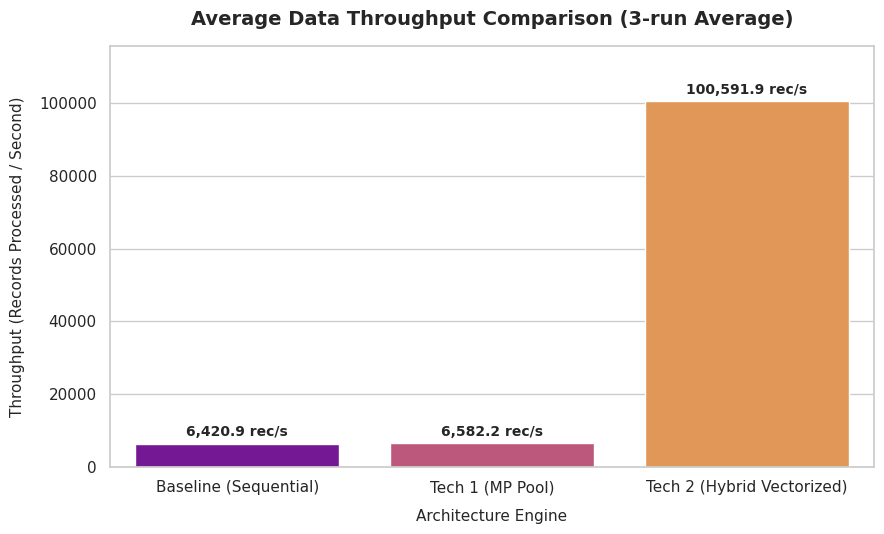

In [9]:
plt.figure(figsize=(9, 5.5))
barplot_thru = sns.barplot(x="Architecture", y="Throughput (records/s)", data=df_eval, palette="plasma")

plt.title("Average Data Throughput Comparison (3-run Average)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Architecture Engine", fontsize=11, labelpad=10)
plt.ylabel("Throughput (Records Processed / Second)", fontsize=11, labelpad=10)
plt.ylim(0, df_eval['Throughput (records/s)'].max() * 1.15)

for patch in barplot_thru.patches:
    barplot_thru.annotate(f"{patch.get_height():,.1f} rec/s",
                          (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                          ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                          fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()